# Code for the Kurnell recalibration example

Specifically Figure 5 and forecast evaluation results

FPT = First Passage Time

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scores.processing import isotonic_fit, broadcast_and_match_nan
from scores.continuous import tw_absolute_error, tw_quantile_score

<details>
<summary>
    <b>Package details</b>
    
Click here to see output of `!pip list`. This will let you see the versions of the packages used at the time when  the notebook was archived.</summary>
    
Package                           Version
--------------------------------- -----------
alabaster                         0.7.16
alembic                           1.8.1
annotated-types                   0.6.0
anyio                             4.2.0
argon2-cffi                       21.3.0
argon2-cffi-bindings              21.2.0
asciitree                         0.3.3
astroid                           3.2.4
asttokens                         2.0.5
async-generator                   1.10
async-lru                         2.0.4
attrs                             23.1.0
Babel                             2.11.0
bandit                            1.7.9
beautifulsoup4                    4.12.3
black                             24.4.2
bleach                            4.1.0
blinker                           1.6.2
bokeh                             3.4.1
bom-jive                          1.24.5
Bottleneck                        1.3.7
branca                            0.6.0
Brotli                            1.0.9
cached-property                   1.5.2
cachetools                        5.3.3
Cartopy                           0.22.0
certifi                           2025.10.5
certipy                           0.1.3
cffi                              1.16.0
cfgv                              3.4.0
cftime                            1.6.2
charset-normalizer                3.3.2
click                             8.1.7
click-plugins                     1.1.1
cligj                             0.7.2
cloudpickle                       3.0.0
colorama                          0.4.6
comm                              0.2.1
commonmark                        0.9.1
contourpy                         1.2.0
coverage                          7.2.2
cryptography                      43.0.0
cx-Oracle                         8.3.0
cycler                            0.11.0
cytoolz                           0.12.2
dask                              2024.5.0
dask-expr                         1.1.0
debugpy                           1.6.7
decorator                         5.1.1
defusedxml                        0.7.1
dill                              0.3.8
distlib                           0.3.8
distributed                       2024.5.0
docopt                            0.6.2
docutils                          0.18.1
entrypoints                       0.4
eta_verification                  0.19.2
executing                         0.8.3
fasteners                         0.16.3
fastjsonschema                    2.16.2
filelock                          3.13.1
fiona                             1.9.6
flake8                            7.0.0
flexcache                         0.3
flexparser                        0.4
folium                            0.14.0
fonttools                         4.51.0
fsspec                            2024.6.1
future                            0.18.3
GDAL                              3.9.2
GeoAlchemy2                       0.15.2
geopandas                         0.14.2
gitdb                             4.0.7
GitPython                         3.1.43
greenlet                          3.0.1
h5py                              3.11.0
HeapDict                          1.0.1
identify                          2.5.5
idna                              3.7
imagesize                         1.4.1
importlib-metadata                7.0.1
iniconfig                         1.1.1
ipykernel                         6.28.0
ipython                           8.25.0
ipython-genutils                  0.2.0
ipywidgets                        8.1.2
isodate                           0.6.1
isort                             5.13.2
jedi                              0.19.1
Jinja2                            3.1.4
jive_adam                         0.4.1
jive_aifs_warnings                0.3.0
jive_ehf                          0.9.1
jive_gfe                          0.12.8
joblib                            1.4.2
json5                             0.9.6
jsonschema                        4.19.2
jsonschema-specifications         2023.7.1
jupyter                           1.0.0
jupyter_client                    7.4.9
jupyter-console                   6.6.3
jupyter-contrib-core              0.4.0
jupyter-contrib-nbextensions      0.7.0
jupyter_core                      5.7.2
jupyter-events                    0.10.0
jupyter-highlight-selected-word   0.2.0
jupyter-kernel-gateway            2.5.0
jupyter-latex-envs                1.4.6
jupyter-lsp                       2.2.0
jupyter-nbextensions-configurator 0.6.1
jupyter_server                    2.14.1
jupyter_server_terminals          0.4.4
jupyter-telemetry                 0.1.0
jupyterhub                        2.3.1
jupyterhub_saml2                  0.9.0
jupyterlab                        4.0.11
jupyterlab_code_formatter         3.0.2
jupyterlab_execute_time           3.1.2
jupyterlab-pygments               0.1.2
jupyterlab_server                 2.25.1
jupyterlab-widgets                3.0.10
kaleido                           0.2.1
kiwisolver                        1.4.4
llvmlite                          0.44.0
lmdb                              1.4.1
locket                            1.0.0
lxml                              5.3.0
lz4                               4.3.2
Mako                              1.2.3
mapclassify                       2.5.0
markdown-it-py                    3.0.0
MarkupSafe                        2.1.3
matplotlib                        3.9.2
matplotlib-inline                 0.1.6
mccabe                            0.7.0
mdit-py-plugins                   0.4.1
mdurl                             0.1.0
memory-profiler                   0.61.0
MetPy                             1.6.3
mistune                           2.0.4
mkl_fft                           1.3.10
mkl_random                        1.2.7
mkl-service                       2.4.0
msgpack                           1.0.3
mypy-extensions                   1.0.0
myst-parser                       3.0.1
nbclassic                         1.1.0
nbclient                          0.8.0
nbconvert                         7.10.0
nbformat                          5.9.2
nest-asyncio                      1.6.0
netCDF4                           1.7.1
networkx                          3.3
nodeenv                           1.7.0
notebook                          6.5.7
notebook_shim                     0.2.3
numba                             0.61.2
numcodecs                         0.12.1
numexpr                           2.8.7
numpy                             1.26.4
oauthlib                          3.2.2
oracledb                          2.1.1
overrides                         7.4.0
packaging                         24.1
pamela                            1.0.0
pandas                            2.1.4
pandocfilters                     1.5.0
parso                             0.8.3
partd                             1.4.1
pathspec                          0.10.3
patsy                             0.5.6
pbr                               5.6.0
pep8                              1.7.1
pexpect                           4.8.0
pillow                            10.4.0
Pint                              0.24.4
pip                               24.2
platformdirs                      3.10.0
plotly                            5.22.0
pluggy                            1.0.0
ply                               3.11
pooch                             1.8.2
pre_commit                        3.8.0
prometheus-client                 0.14.1
prompt-toolkit                    3.0.43
psutil                            5.9.0
psycopg2                          2.9.9
ptyprocess                        0.7.0
pure-eval                         0.2.2
pyarrow                           17.0.0
pycodestyle                       2.11.1
pycparser                         2.21
pycurl                            7.45.3
pydantic                          2.8.2
pydantic_core                     2.20.1
pyflakes                          3.2.0
Pygments                          2.15.1
PyJWT                             2.8.0
pylint                            3.2.2
pyOpenSSL                         24.2.1
pyparsing                         3.1.2
pyproj                            3.6.1
PyQt5                             5.15.10
PyQt5-sip                         12.13.0
pyshp                             2.3.1
PySocks                           1.7.1
pytest                            7.4.4
pytest-cov                        4.1.0
pytest-runner                     6.0.0
python-dateutil                   2.9.0.post0
python-json-logger                2.0.7
python3-saml                      1.9.0
pytz                              2024.1
PyYAML                            6.0.1
pyzmq                             25.1.2
qtconsole                         5.5.1
QtPy                              2.4.1
recommonmark                      0.6.0
referencing                       0.30.2
requests                          2.32.3
rfc3339-validator                 0.1.4
rfc3986-validator                 0.1.1
rich                              10.16.2
rpds-py                           0.10.6
Rtree                             1.0.1
ruamel.yaml                       0.18.6
ruamel.yaml.clib                  0.2.8
scikit-learn                      1.5.1
scipy                             1.13.1
scores                            2.2.0
scoringrules                      0.8.0
seaborn                           0.13.2
Send2Trash                        1.8.2
setuptools                        72.1.0
shapely                           2.0.6
sip                               6.7.12
six                               1.16.0
smmap                             4.0.0
sniffio                           1.3.0
snowballstemmer                   2.2.0
sortedcontainers                  2.4.0
soupsieve                         2.5
Sphinx                            7.3.7
sphinx_rtd_theme                  2.0.0
sphinxcontrib-applehelp           1.0.2
sphinxcontrib-devhelp             1.0.2
sphinxcontrib-htmlhelp            2.0.0
sphinxcontrib-jquery              4.1
sphinxcontrib-jsmath              1.0.1
sphinxcontrib-qthelp              1.0.3
sphinxcontrib-serializinghtml     1.1.10
SQLAlchemy                        1.4.49
stack-data                        0.2.0
statsmodels                       0.14.2
stevedore                         5.3.0
tblib                             1.7.0
tenacity                          8.2.3
terminado                         0.17.1
threadpoolctl                     3.5.0
tinycss2                          1.2.1
toml                              0.10.2
tomli                             2.0.1
tomlkit                           0.11.1
toolz                             0.12.0
tornado                           6.4.1
traitlets                         5.14.3
typing_extensions                 4.11.0
tzdata                            2023.3
ukkonen                           1.0.1
unicodedata2                      15.1.0
urllib3                           2.2.2
virtualenv                        20.26.1
wcwidth                           0.2.5
webencodings                      0.5.1
websocket-client                  1.8.0
wheel                             0.43.0
widgetsnbextension                4.0.10
xarray                            2024.7.0
xgboost                           2.1.1
xmlsec                            1.3.14
xmltodict                         0.13.0
xyzservices                       2022.9.0
zarr                              2.18.2
zict                              3.0.0
zipp                              3.17.0
    
</details>

In [2]:
# dummy value to assign FPT observations and forecasts that exceed 18 hours
# (the censoring time)
DUMMY_VALUE = 1000

# FPT crossing threshold, in knots
THLD = 15

# quantile levels for the interquartile range (IQR)
LOWER_LEVEL = 0.25
UPPER_LEVEL = 0.75

## Some functions

In [3]:
# code for calcaulting first passage time forecasts via linear interpolation.

def get_fpt(fcst_series, threshold, period_valid_start, min_length):
    """
    Calculates the first passage time for a sequence of forecasts within a
    designated 18-hour period.
    
    The first passage time is the first time, in hours since the start of the
    18-hour period, that the forecast time series crosses the specified
    `threshold` value, calculated using linear interpolation.
    
    Args:
        fcst_series: a pandas series of forecast values. Each index value is a
            pd.Timestamp, and the index increasing.
        threshold: the threshold value to cross
        period_valid_start: pd.Timestamp indicating the start of the 18-hour
            period
        min_length: the minimum length of the forecast time series within the
            specified period for a non-NaN value to be returned. NaN values in
            the forecast are dropped prior to calculating the length.
    
    Returns:
        - `np.nan` if the specified period does not have sufficient forecast
            data, as specified by `min_length`
        - `np.inf` if the threshold is not exceeded in the forecast data the
            specific period.
        - `0` if the first forecast in the period exceeds the threshold
        - the first crossing point, in hours since the start of the period as
            calculated by linear interpolation, otherwise.
    """
    period_valid_end = period_valid_start + pd.Timedelta(18, 'hours')
    period_fcst = fcst_series[
        (fcst_series.index >= period_valid_start) & (fcst_series.index <= period_valid_end)
    ].dropna()   
    
    if len(period_fcst) < min_length:
        return np.nan
    if period_fcst.max() <= threshold:
        return np.inf
    
    if period_fcst.iloc[0] > threshold:
        return (period_fcst.index[0] - period_valid_start).total_seconds() / 3600
    
    else:
        # get the first time that forecast exceeded threshold and corresponding forecast value
        series_exceedances = period_fcst.loc[period_fcst > threshold]
        fcst_at_exceedance = series_exceedances.iloc[0]
        time_at_exceedance = series_exceedances.index[0]
        
        # get the time and forecast value immediately prior to first exceedance
        series_before_exceedance = period_fcst.loc[period_fcst.index < time_at_exceedance]
        fcst_before_exceedance = series_before_exceedance.iloc[-1]
        time_before_exceedance = series_before_exceedance.index[-1]
        
        # interpolate to find first passage time in hours since period_valid_start
        hours_delta = (time_at_exceedance - time_before_exceedance).total_seconds() / 3600
        fcst_delta = fcst_at_exceedance - fcst_before_exceedance
        
        first_passage_time = (threshold - fcst_before_exceedance) * hours_delta / fcst_delta
        first_passage_time += (time_before_exceedance - period_valid_start).total_seconds() / 3600     
    
        return first_passage_time


def get_fpts(fcst_series, threshold, min_length):
    """
    Gets all the first passage time (FPT) forecasts given a time series of
    forecasts and the crossing threshold.
    
    FPT forecasts are for all 18-hour periods, starting at 18UTC, that intersect
    with the time index in `fcst_series`.
    
    Args:
        fcst_series: pd.Series of forecast values, indexed by an increasing
            sequence of pd.Timestamps
        threshold: the crossing threshold
        min_length: minimum number of forecast values in an 18-hour validity
            period required to output a non-NaN FPT forecast.
            
    Returns:
        pd.Series of FPT forecasts, indexed by the start time of each 18-hour
        validity period. A FPT forecast is given the values as documented in the
        `get_fpt` docstring.        
    """
    standard_local_date = (fcst_series.index + pd.Timedelta(10, 'hours')).date
    period_valid_starts = pd.to_datetime(standard_local_date) - pd.Timedelta(6, 'hours')
    period_valid_starts = np.unique(period_valid_starts)
    
    fpt = []
    for period_valid_start in period_valid_starts:
        fpt_for_period = get_fpt(fcst_series, threshold, period_valid_start, min_length)
        fpt.append(fpt_for_period)
    result = pd.Series(fpt, index=period_valid_starts)
    result.index.name = 'validity_period_start'
    return result


def calibrate_using_isotonic_fit(isofit, fcst):
    """
    Use isotonic regression output to conditionally bias correct the forecast.
    
    Maps forecast values to calibrated values using the isotonic solution
    contained in `isofit`.
    
    The isotonic fit maps values from the interval `[a,b]` to the interval `[c,d]`,
    as determined by the training data. In cases where values in `fcst` lie outside `[a,b]`:
        - `fcst` is mapped to `max(fcst, d)` if `fcst > d`
        - `fcst` is mapped to `min(fcst, c)` if `fcst < a`
    
    Args:
        isofit: output from `scores.processing.isotonic_fit` using training forecast
            and observation data.
        fcst: validation forecast values, in array format.
        
    Returns:
        array of bias corrected forecast values
    """
    min_isofit_x = np.min(isofit['fcst_sorted'])
    max_isofit_x = np.max(isofit['fcst_sorted'])
    min_isofit_y = np.min(isofit['regression_values'])
    max_isofit_y = np.max(isofit['regression_values'])
    
    calibrated_fcst = xr.full_like(fcst, np.nan)
    calibrated_fcst.values = isofit['regression_func'](fcst)
    
    # Deal with cases where `fcst` lies outside the interval `[a,b]`  
    calibrated_fcst = calibrated_fcst.where(fcst <= max_isofit_x, fcst.clip(min=max_isofit_y))
    calibrated_fcst = calibrated_fcst.where(fcst >= min_isofit_x, fcst.clip(max=min_isofit_y))
    
    # ensure NaNs in fcst are preserved
    calibrated_fcst = calibrated_fcst.where(~np.isnan(fcst), np.nan)
    
    return calibrated_fcst


def data_for_year(dataarray, year, time_dim):
    """
    Extracts data from dataarray for 18-hour validity periods that belong to the
    specified year (in standard local time).
    
    Args:
        dataarray: data array with dimension `time_dim`
        year: integer specifying the calendar year, e.g. 2023
        time_dim: time dimension in dataarray, with coordinates pd.Timestamp in UTC.
        
    Returns:
        subset of data from dataarray belonging to the specified year.
    """
    result = dataarray.sel({time_dim: slice(
        pd.Timestamp(f'{year - 1}-12-31 18:00:00'), pd.Timestamp(f'{year}-12-31 12:00:00')
    )})
    return result

In [4]:
# Unit tests for get_fpt

test_fcst = pd.Series(
    [16.0, 10, 8, 12, 18, 14, 6, 2, 8],
    index=[
        pd.Timestamp('2020-03-02 18:00:00') + pd.Timedelta(x, 'hours') 
        for x in [-2, 0, 1, 2, 3, 4, 18, 20, 27]
    ]
)

# test simple linear interpolation
result = get_fpt(test_fcst, 15, pd.Timestamp('2020-03-02 18:00:00'), 6)
expected = 2.5
np.testing.assert_allclose(result, expected)

# different interpolation
result = get_fpt(test_fcst, 16, pd.Timestamp('2020-03-02 18:00:00'), 6)
expected = 2 + 2/3
np.testing.assert_allclose(result, expected)

# test when fcst exceeds threshold at start of period
result = get_fpt(test_fcst, 9.9, pd.Timestamp('2020-03-02 18:00:00'), 6)
expected = 0
np.testing.assert_allclose(result, expected)

# test when fcst exceeds threshold for first timestep in period
result = get_fpt(test_fcst, 7, pd.Timestamp('2020-03-03 18:00:00'), 1)
expected = 3
np.testing.assert_allclose(result, expected)

# test when min_length not met
result = get_fpt(test_fcst, 9.9, pd.Timestamp('2020-03-02 18:00:00'), 7)
expected = np.nan
np.testing.assert_allclose(result, expected)

# test when data for period is empty
result = get_fpt(test_fcst, 9.9, pd.Timestamp('2019-03-02 18:00:00'), 1)
expected = np.nan
np.testing.assert_allclose(result, expected)

# test when threshold never exceeded
result = get_fpt(test_fcst, 18, pd.Timestamp('2020-03-02 18:00:00'), 6)
expected = np.inf
np.testing.assert_allclose(result, expected)

In [5]:
# Unit test for calibrate_using_isotonic_fit
# This is mainly to check that:
# 1. NaNs in fcst are preserved
# 2. extreme values are correctly mapped.

test_isofit = isotonic_fit(np.array([2., 5, 3, 7, 5]), np.array([1., 4, 6, 8, 7]))

test_fcst = xr.DataArray([1.5, -1, np.nan, 4, 7.5, 8.5])
result = calibrate_using_isotonic_fit(test_isofit, test_fcst)
expected = xr.DataArray([1., -1, np.nan, 5.66666667, 8, 8.5])
xr.testing.assert_allclose(expected, result)

## Hourly wind speed data, including bias correction

In [6]:
# hourly access wind speed forecasts
hourly_fcst = xr.open_dataarray('data/kurnel_hourly_windmag_forecasts.nc')
hourly_fcst

ERROR 1: PROJ: proj_create_from_database: Open of /work/autogfe/miniconda3/envs/jupyterhub/share/proj failed


<xarray.DataArray 'windmag' (time: 13840)> Size: 111kB
[13840 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 111kB 2022-12-31T18:00:00 ... 2024-12-31T1...
Attributes:
    description:  forecast wind speed in knots from ACCESS model at Kurnell
    time:         timestamp of the forecast wind speed
    Note:         This array only contains the +18h to +36h forecasts from ea...

In [7]:
# separate into forecasts for 2023 and 2024
hourly_fcst_2023 = data_for_year(hourly_fcst, 2023, 'time')
hourly_fcst_2024 = data_for_year(hourly_fcst, 2024, 'time')

In [8]:
# get the hourly wind speed observations
hourly_obs = xr.open_dataarray('data/kurnel_hourly_windmag_observations.nc')
hourly_obs

<xarray.DataArray 'windmag' (time: 17492)> Size: 140kB
[17492 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 140kB 2022-12-31T15:00:00 ... 2024-12-31T1...
Attributes:
    parameter:    WindMag
    unit:         kt
    source_id:    aws_hourly
    description:  Observed 10-minute mean wind speed at Kurnell weather station

In [9]:
# Get the data to be used for wind speed bias correction (bc)
data_bc = xr.merge(
    [
        hourly_fcst.rename('fcst'),
        hourly_obs.rename('obs')
    ]
).to_dataframe()

# get data for 2023 (standard local time), between hours 18UTC to 12 UTC
data_bc.index =  pd.to_datetime(data_bc.index)
data_bc = data_bc[(data_bc.index.hour >= 18) | (data_bc.index.hour <= 12)]
data_bc = data_bc[data_bc.index <= pd.Timestamp('2023-12-31 12:00:00')]

# drop any rows with NaN, as these cannot be used for bias correction
data_bc = data_bc.dropna()
data_bc

,fcst,obs
time,,
2022-12-31 18:00:00,3.0,0.0
2022-12-31 19:00:00,5.0,2.0
2022-12-31 20:00:00,5.2,0.0
2022-12-31 21:00:00,7.0,8.9
2022-12-31 22:00:00,5.9,12.2
...,...,...
2023-12-31 08:00:00,7.3,6.4
2023-12-31 09:00:00,6.7,6.8
2023-12-31 10:00:00,5.3,7.7


In [10]:
# Using isotonic regression with squared loss, regress 2023 wind speed forecasts against observations
access_windspeed_isofit = isotonic_fit(np.array(data_bc['fcst']), np.array(data_bc['obs']))

In [11]:
# ACCESS (2023 data) conditional wind speed bias, conditioned on a forecast of 12 knots:
fcst_value = 12
fcst_value - access_windspeed_isofit['regression_func'](fcst_value)

-3.105000000000002

In [12]:
# get the bias corrected forecasts
hourly_fcst_bc = calibrate_using_isotonic_fit(access_windspeed_isofit, hourly_fcst)
hourly_fcst_bc.attrs['description'] = 'bias corrected wind speed forecast in knots, using 2023 data for bias calculations'
hourly_fcst_bc

<xarray.DataArray 'windmag' (time: 13840)> Size: 111kB
array([6.17155963, 7.03718412, 7.03718412, ..., 6.7892779 , 6.17155963,
       6.17155963])
Coordinates:
  * time     (time) datetime64[ns] 111kB 2022-12-31T18:00:00 ... 2024-12-31T1...
Attributes:
    description:  bias corrected wind speed forecast in knots, using 2023 dat...
    time:         timestamp of the forecast wind speed
    Note:         This array only contains the +18h to +36h forecasts from ea...

In [13]:
# split into 2023 and 2024 data
hourly_fcst_bc_2023 = data_for_year(hourly_fcst_bc, 2023, 'time')
hourly_fcst_bc_2024 = data_for_year(hourly_fcst_bc, 2024, 'time')

## Creation of FPT IQR forecasts

In [14]:
# FPT observations; these have been processed from wind observations with one-minute
# reporting frequency

fpt_obs_dataset = xr.open_dataset('data/kurnell_FPT_observations.nc')
fpt_obs_dataset

<xarray.Dataset> Size: 18kB
Dimensions:                (validity_period_start: 731)
Coordinates:
  * validity_period_start  (validity_period_start) datetime64[ns] 6kB 2022-12...
Data variables:
    first_passage_time     (validity_period_start) float64 6kB ...
    obs_count              (validity_period_start) int64 6kB ...
Attributes:
    validity_period_start:  start time of each 18 hour validity period
    first_passage_time:     hours since validity_period_start when the observ...
    obs_count:              The number of one-minute wind speed observations ...

In [15]:
# These FPT obs need some additional processing.
# First replace NaNs with the dummy value
fpt_obs = fpt_obs_dataset['first_passage_time'].where(fpt_obs_dataset['first_passage_time'].notnull(), DUMMY_VALUE)

# Then NaN observations that have been created when more than 10% of wind speed
# obs data was missing in the period
fpt_obs = fpt_obs.where(fpt_obs_dataset['obs_count'] >= 1081 * 0.9)


# split into 2023/24 data
fpt_obs_2023 = data_for_year(fpt_obs, 2023, 'validity_period_start')
fpt_obs_2024 = data_for_year(fpt_obs, 2024, 'validity_period_start')

fpt_obs

<xarray.DataArray 'first_passage_time' (validity_period_start: 731)> Size: 6kB
array([6.28333333e+00, 6.66666667e+00, 7.46666667e+00, 5.35000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.53333333e+00,
       1.00000000e+03, 7.63333333e+00, 1.00000000e+03, 1.25000000e+01,
       9.31666667e+00, 6.25000000e+00, 4.91666667e+00, 1.00000000e+03,
       7.25000000e+00, 5.60000000e+00,            nan, 7.50000000e-01,
       1.25666667e+01, 1.80000000e+00, 5.43333333e+00, 1.00333333e+01,
       1.00000000e+03, 8.78333333e+00, 0.00000000e+00, 8.16666667e+00,
       1.00000000e+03, 5.28333333e+00, 0.00000000e+00, 5.18333333e+00,
       5.86666667e+00, 5.88333333e+00, 2.05000000e+00, 1.00000000e+03,
       5.81666667e+00, 1.00000000e+03, 8.41666667e+00, 5.83333333e-01,
       1.12000000e+01, 7.60000000e+00, 1.33333333e-01, 1.30000000e+00,
       0.00000000e+00, 9.63333333e+00, 7.45000000e+00, 5.76666667e+00,
       6.48333333e+00, 0.00000000e+00, 7.35000000e+00, 1.28166667e+01,
       0.00000000e+00, 2.00000000e-01, 1.09500000e+01, 7.15000000e+00,
       8.91666667e+00, 0.00000000e+00, 1.11666667e+01, 5.43333333e+00,
       1.00000000e+03, 7.71666667e+00, 1.00000000e+03, 5.96666667e+00,
       5.03333333e+00, 6.36666667e+00, 1.00000000e+03, 1.00000000e+03,
       9.35000000e+00, 8.65000000e+00, 0.00000000e+00, 1.90000000e+00,
       5.35000000e+00, 1.00000000e+03, 1.23833333e+01, 0.00000000e+00,
       7.75000000e+00, 1.00000000e+03, 0.00000000e+00, 1.00000000e+03,
...
       1.01333333e+01, 0.00000000e+00, 1.00000000e+03, 6.51666667e+00,
       8.23333333e+00, 1.09666667e+01, 3.33333333e-02, 0.00000000e+00,
       1.15000000e+01, 1.22166667e+01, 1.05000000e+00, 9.40000000e+00,
       0.00000000e+00, 8.81666667e+00, 5.48333333e+00, 1.00000000e+03,
       6.41666667e+00, 9.96666667e+00, 1.17333333e+01, 9.00000000e+00,
       6.15000000e+00, 0.00000000e+00, 9.16666667e+00, 4.78333333e+00,
       7.43333333e+00, 4.48333333e+00, 7.21666667e+00, 3.96666667e+00,
       8.40000000e+00, 1.00000000e+03, 9.16666667e+00, 9.00000000e-01,
       1.25833333e+01, 1.66666667e-02, 2.51666667e+00, 9.13333333e+00,
       1.00000000e+03, 1.27666667e+01, 8.25000000e+00, 5.08333333e+00,
       5.61666667e+00, 5.48333333e+00, 5.48333333e+00, 7.00000000e+00,
       7.45000000e+00, 1.54333333e+01, 3.25000000e+00, 8.66666667e-01,
       7.88333333e+00, 9.61666667e+00, 7.40000000e+00, 0.00000000e+00,
       1.06666667e+01, 9.95000000e+00, 6.65000000e+00, 6.23333333e+00,
       9.80000000e+00, 4.05000000e+00, 8.68333333e+00, 1.00000000e+03,
       8.81666667e+00, 2.58333333e+00, 5.25000000e+00, 7.75000000e+00,
       6.23333333e+00, 0.00000000e+00, 4.88333333e+00, 3.86666667e+00,
       1.00000000e+03, 1.00000000e+03, 3.83333333e+00, 3.18333333e+00,
       8.63333333e+00, 4.91666667e+00, 7.66666667e-01, 9.61666667e+00,
       8.88333333e+00, 1.14666667e+01, 1.00000000e+03])
Coordinates:
  * validity_period_start  (validity_period_start) datetime64[ns] 6kB 2022-12...

In [16]:
# Create the FPT forecasts (deterministic) based on ACCESS wind speeds
# (not bias corrected)
uncalibrated_fpt_fcst = get_fpts(hourly_fcst.to_dataframe()['windmag'], THLD, 17).to_xarray()
uncalibrated_fpt_fcst = uncalibrated_fpt_fcst.where(uncalibrated_fpt_fcst < np.inf, DUMMY_VALUE)

# split into 2023/24 data
uncalibrated_fpt_fcst_2023 = data_for_year(uncalibrated_fpt_fcst, 2023, 'validity_period_start')
uncalibrated_fpt_fcst_2024 = data_for_year(uncalibrated_fpt_fcst, 2024, 'validity_period_start')

uncalibrated_fpt_fcst_2023

<xarray.DataArray (validity_period_start: 365)> Size: 3kB
array([1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.53529412e+01,
       0.00000000e+00, 5.00000000e+00, 0.00000000e+00, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 8.14285753e+00, 0.00000000e+00, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 0.00000000e+00, 9.20000000e+00,
       8.34782614e+00, 1.14444444e+01, 1.00000000e+03, 1.00000000e+03,
       8.78947384e+00, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.54666665e+01,
       1.00000000e+03, 9.23529405e+00, 3.74336286e+00, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       9.37500015e+00, 0.00000000e+00, 1.00000000e+03, 1.30555556e+01,
       0.00000000e+00, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 5.86363627e+00,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.02333333e+01, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 7.00000000e+00, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 7.73239440e+00,
       1.00000000e+03, 1.00000000e+03, 2.44444450e+00, 1.00000000e+03,
...
       9.16949154e+00, 2.70491813e+00, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 8.33333333e+00, 1.00000000e+03, 1.00000000e+03,
       9.94736824e+00, 2.86567169e+00, 1.72727265e+00, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 8.77142852e+00, 1.01071429e+01,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       6.97297288e+00, 8.96296283e+00, 7.89285708e+00, 1.45555558e+01,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       0.00000000e+00, 1.00000000e+03, 9.07142886e+00, 1.00000000e+03,
       1.00000000e+03, 7.50000000e+00, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.61000000e+01,
       0.00000000e+00, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       8.59999987e+00, 1.00000000e+03, 7.75000030e+00, 0.00000000e+00,
       1.00000000e+03, 8.90909059e+00, 1.01081080e+01, 0.00000000e+00,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.68447205e+01,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.17499999e+01, 0.00000000e+00, 3.48387091e+00, 5.84999990e+00,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       6.95238092e+00, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03])
Coordinates:
  * validity_period_start  (validity_period_start) datetime64[ns] 3kB 2022-12...

In [17]:
# Create the FPT forecasts (deterministic) based on 2023 bias corrected ACCESS wind speeds
# These are uncalibrated as a quantile FPT forecast
uncal_fpt_fcst_bc_2023 = get_fpts(hourly_fcst_bc_2023.to_series(), THLD, 17).to_xarray()
uncal_fpt_fcst_bc_2023 = uncal_fpt_fcst_bc_2023.where(uncal_fpt_fcst_bc_2023 < np.inf, DUMMY_VALUE)
uncal_fpt_fcst_bc_2023

<xarray.DataArray (validity_period_start: 365)> Size: 3kB
array([8.88767193e+00, 7.93182325e+00, 5.96681018e+00, 1.17269278e+01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+03,
       1.00000000e+03, 1.09445132e+01, 1.00000000e+03, 1.00000000e+03,
       1.00000000e+03, 7.93182325e+00, 6.26492211e+00, 1.00000000e+03,
       1.00000000e+03, 5.11663132e+00, 0.00000000e+00, 8.97931230e+00,
       1.00000000e+03, 1.38930310e+01, 6.97171848e+00, 1.00000000e+03,
       1.00000000e+03, 1.49806796e+01, 0.00000000e+00, 6.85150281e+00,
       4.96608935e+00, 3.96681018e+00, 0.00000000e+00, 1.00000000e+03,
       6.75823595e+00, 1.00000000e+03, 5.98266209e+00, 1.00000000e+03,
       8.94451319e+00, 1.17660167e+01, 1.00000000e+03, 7.93369197e+00,
       9.72692777e+00, 7.27887874e+00, 3.55449226e+00, 0.00000000e+00,
       5.45483491e+00, 1.00000000e+03, 7.96608935e+00, 6.94451319e+00,
       6.86579668e+00, 0.00000000e+00, 6.72692777e+00, 1.26718147e+01,
       0.00000000e+00, 4.62742343e+00, 1.00000000e+03, 1.00000000e+03,
       1.07269278e+01, 1.00000000e+03, 1.27660167e+01, 4.87155709e+00,
       1.00000000e+03, 1.26956548e+01, 1.00000000e+03, 7.13827113e+00,
       4.85150281e+00, 1.00000000e+03, 1.00000000e+03, 1.00000000e+03,
       9.96608935e+00, 1.07269278e+01, 0.00000000e+00, 0.00000000e+00,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 7.38736038e+00,
       6.82155990e+00, 1.00000000e+03, 0.00000000e+00, 9.44513194e-01,
...
       8.77393142e+00, 0.00000000e+00, 1.00000000e+03, 1.00000000e+03,
       7.72692777e+00, 6.52444715e+00, 1.00000000e+03, 1.00000000e+03,
       8.60073887e+00, 2.48758843e+00, 0.00000000e+00, 1.00000000e+03,
       1.00000000e+03, 8.52444715e+00, 4.97931230e+00, 5.58772058e+00,
       1.00000000e+03, 1.00000000e+03, 1.19717185e+01, 4.62706567e+00,
       0.00000000e+00, 1.00000000e+03, 7.97171848e+00, 1.17269278e+01,
       6.24167822e+00, 7.96608935e+00, 6.94451319e+00, 1.33621965e+01,
       1.00000000e+03, 6.88767193e+00, 2.93369197e+00, 1.19660894e+01,
       0.00000000e+00, 8.72692777e+00, 6.72692777e+00, 9.76601671e+00,
       1.00000000e+03, 1.27918657e+00, 1.93182325e+00, 1.09336920e+01,
       1.18515028e+01, 1.18509562e+01, 0.00000000e+00, 5.93369197e+00,
       0.00000000e+00, 1.00000000e+03, 1.25826955e+01, 1.00000000e+03,
       7.79090063e+00, 1.00000000e+03, 6.24167822e+00, 0.00000000e+00,
       1.00000000e+03, 6.90563273e+00, 7.60786357e+00, 0.00000000e+00,
       1.00000000e+03, 1.00000000e+03, 6.26492211e+00, 8.97381272e+00,
       9.26492211e+00, 1.49840355e+01, 1.07660167e+01, 1.08876719e+01,
       7.27918657e+00, 0.00000000e+00, 2.97171848e+00, 9.44513194e-01,
       1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 1.34548349e+01,
       6.69957171e+00, 1.00000000e+03, 1.00000000e+03, 8.65204253e+00,
       1.00000000e+03])
Coordinates:
  * validity_period_start  (validity_period_start) datetime64[ns] 3kB 2022-12...

In [18]:
# Regress FPT forecasts, derived from 2023 bias-corrected wind speeds, against FPT observations,
# using isotonic regression with quantile loss
fpt_fcst_training, fpt_obs_training = broadcast_and_match_nan(uncal_fpt_fcst_bc_2023, fpt_obs_2023)
isofit_fpt_lower = isotonic_fit(fpt_fcst_training, fpt_obs_training, functional='quantile', quantile_level=LOWER_LEVEL)
isofit_fpt_upper = isotonic_fit(fpt_fcst_training, fpt_obs_training, functional='quantile', quantile_level=UPPER_LEVEL)

In [19]:
# An original FPT forecast of 8 is mapped to the following IQR forecast using the regression:
(isofit_fpt_lower['regression_func'](8), isofit_fpt_upper['regression_func'](8))

(array(5.875), array(7.65))

In [20]:
# Create FPT forecasts for 2024 from bias corrected ACCESS wind speeds.
# The FPT forecasts aren't calibrated
uncal_fpt_fcst_bc_2024 = get_fpts(hourly_fcst_bc_2024.to_series(), THLD, 17).to_xarray()
uncal_fpt_fcst_bc_2024 = uncal_fpt_fcst_bc_2024.where(uncal_fpt_fcst_bc_2024 < np.inf, DUMMY_VALUE)

In [21]:
# Now create the calibrated IQR FPT forecasts for 2024, using calibration learned from 2023 data
calibrated_fpt_lower_2024 = calibrate_using_isotonic_fit(isofit_fpt_lower, uncal_fpt_fcst_bc_2024)
calibrated_fpt_upper_2024 = calibrate_using_isotonic_fit(isofit_fpt_upper, uncal_fpt_fcst_bc_2024)

## Calculate the interval scores  $\mathrm{twIS}_{0.5, 18}$

Here, the evaluation time $\tau$ is 18 hours.

In [22]:
# Deterministic ACCESS 2023 forecasts
twis_access_2023 = tw_quantile_score(uncalibrated_fpt_fcst_2023, fpt_obs_2023, LOWER_LEVEL, (0,18))
twis_access_2023 += tw_quantile_score(uncalibrated_fpt_fcst_2023, fpt_obs_2023, UPPER_LEVEL, (0,18))
twis_access_2023

<xarray.DataArray ()> Size: 8B
array(6.56106827)

In [23]:
# Deterministic ACCESS 2024 forecasts
twis_access_2024 = tw_quantile_score(uncalibrated_fpt_fcst_2024, fpt_obs_2024, LOWER_LEVEL, (0,18))
twis_access_2024 += tw_quantile_score(uncalibrated_fpt_fcst_2024, fpt_obs_2024, UPPER_LEVEL, (0,18))
twis_access_2024

<xarray.DataArray ()> Size: 8B
array(6.02204886)

In [24]:
# Does deriving FPT from bias-corrected ACCESS wind speed forecasts improve the result for 2024?
# Recall that the bias adjustment is based on 2023 training data.
# Note that the FPT forecasts here have not been calibrated.
twis_access_bc_2024 = tw_quantile_score(uncal_fpt_fcst_bc_2024, fpt_obs_2024, LOWER_LEVEL, (0,18))
twis_access_bc_2024 += tw_quantile_score(uncal_fpt_fcst_bc_2024, fpt_obs_2024, UPPER_LEVEL, (0,18))
twis_access_bc_2024

# That's a substantial reduction of error. These results are not shown in the paper.

<xarray.DataArray ()> Size: 8B
array(3.55513806)

In [25]:
# Now assess fully calibrated 2024 FPT IQR forecasts (calibrated using 2023 training data)
twis_calibrated_2024 = tw_quantile_score(calibrated_fpt_lower_2024, fpt_obs_2024, LOWER_LEVEL, (0,18))
twis_calibrated_2024 += tw_quantile_score(calibrated_fpt_upper_2024, fpt_obs_2024, UPPER_LEVEL, (0,18))
twis_calibrated_2024

# That's another substantial reduction in error from twis_access_bc_2024

<xarray.DataArray ()> Size: 8B
array(2.65669726)

## Code for Figure 5

In [26]:
# Need isotonic fits for 2024 FPT forecasts regressed against 2024 FPT obs
isofit_uncal_lower_2024 = isotonic_fit(
    uncalibrated_fpt_fcst_2024, fpt_obs_2024, functional='quantile', quantile_level=LOWER_LEVEL
)
isofit_uncal_upper_2024 = isotonic_fit(
    uncalibrated_fpt_fcst_2024, fpt_obs_2024, functional='quantile', quantile_level=UPPER_LEVEL
)
isofit_cal_lower_2024 = isotonic_fit(
    calibrated_fpt_lower_2024, fpt_obs_2024, functional='quantile', quantile_level=LOWER_LEVEL
)
isofit_cal_upper_2024 = isotonic_fit(
    calibrated_fpt_upper_2024, fpt_obs_2024, functional='quantile', quantile_level=UPPER_LEVEL
)

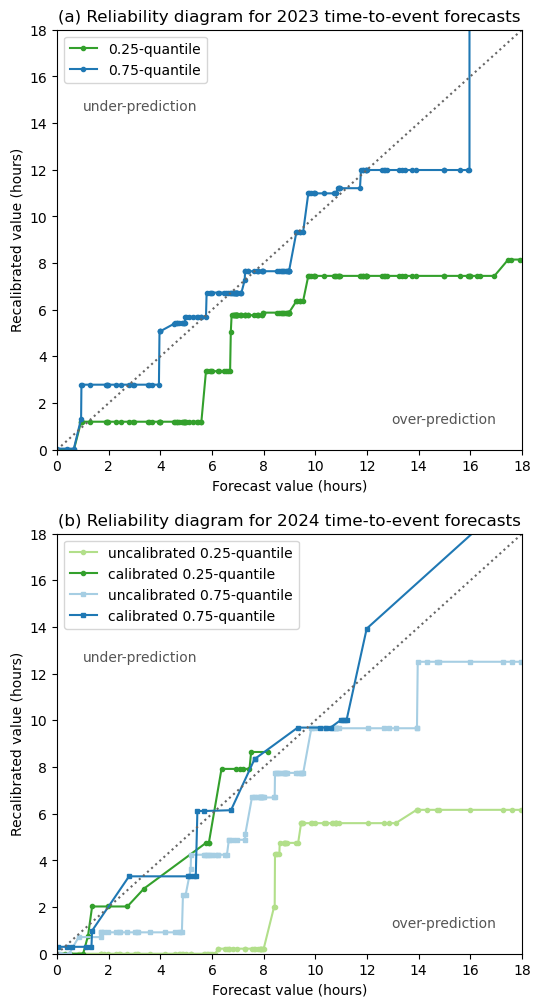

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(6, 12)) # 1 row, 2 columns

# annotation colour
ancol = '#555555'


# first plot

axes[0].plot(
    isofit_fpt_lower['fcst_sorted'], 
    isofit_fpt_lower['regression_values'], 
    color='#33a02c', 
    linestyle='-', marker='o', markersize=3,
    label='0.25-quantile'
)
axes[0].plot(
    isofit_fpt_upper['fcst_sorted'], 
    isofit_fpt_upper['regression_values'], 
    color='#1f78b4', 
    linestyle='-', marker='o', markersize=3,
    label='0.75-quantile'
)
axes[0].plot(
    [0, 18], 
    [0, 18],
    color='#666666', 
    linestyle='dotted'
)

axes[0].text(17, 1, "over-prediction", fontsize=10, color=ancol, ha='right', va='bottom')
axes[0].text(1, 15, "under-prediction", fontsize=10, color=ancol, ha='left', va='top')


axes[0].set_xlim(0, 18)
axes[0].set_ylim(0, 18)

axes[0].set_xlabel("Forecast value (hours)")
axes[0].set_ylabel("Recalibrated value (hours)")
axes[0].set_title("(a) Reliability diagram for 2023 time-to-event forecasts")
#plt.grid(True) # Adds a grid to the plot

axes[0].legend(loc='upper left')

# second plot

axes[1].plot(
    isofit_uncal_lower_2024['fcst_sorted'], 
    isofit_uncal_lower_2024['regression_values'], 
    color='#b2df8a', 
    linestyle='-', marker='o', markersize=3,
    label='uncalibrated 0.25-quantile'
)
axes[1].plot(
    isofit_cal_lower_2024['fcst_sorted'], 
    isofit_cal_lower_2024['regression_values'], 
    color='#33a02c', 
    linestyle='-', marker='o', markersize=3,
    label='calibrated 0.25-quantile'
)
axes[1].plot(
    isofit_uncal_upper_2024['fcst_sorted'], 
    isofit_uncal_upper_2024['regression_values'], 
    color='#a6cee3', 
    linestyle='-', marker='s', markersize=3,
    label='uncalibrated 0.75-quantile'
)
axes[1].plot(
    isofit_cal_upper_2024['fcst_sorted'], 
    isofit_cal_upper_2024['regression_values'], 
    color='#1f78b4', 
    linestyle='-', marker='s', markersize=3,
    label='calibrated 0.75-quantile'
)



axes[1].plot(
    [0, 18], 
    [0, 18],
    color='#666666', 
    linestyle='dotted'
)

axes[1].text(17, 1, "over-prediction", fontsize=10, color='#555555', ha='right', va='bottom')
axes[1].text(1, 13, "under-prediction", fontsize=10, color='#555555', ha='left', va='top')


axes[1].set_xlim(0, 18)
axes[1].set_ylim(0, 18)

axes[1].set_xlabel("Forecast value (hours)")
axes[1].set_ylabel("Recalibrated value (hours)")
axes[1].set_title("(b) Reliability diagram for 2024 time-to-event forecasts")
#plt.grid(True) # Adds a grid to the plot

axes[1].legend(loc='upper left')

# plt.savefig("../../paper_images/wind_reliability.png", dpi=600, bbox_inches='tight')

plt.show()

## Statistics on the 2023 training data set

In [28]:
# proportion of periods where the threshold was exceeded
fpt_obs_training.where(fpt_obs_training <= 18).count() / 365

<xarray.DataArray 'first_passage_time' ()> Size: 8B
array(0.7260274)

In [29]:
# proportion of period where bias corrected wind speed forecasts resulted in
# threshold exceedance during the period
fpt_fcst_training.where(fpt_fcst_training <= 18).count() / 365

<xarray.DataArray ()> Size: 8B
array(0.54246575)